# What is the pay for different Data roles?

## Steps:

1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analyst
3. Visualize for the highest paying skills and most demanding skills

In [2]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [21]:
df_DA_Salaries = df[(df['job_country'].isin(['United States', 'Mexico', 'Germany', 'UK']))].dropna(subset='salary_year_avg').copy()

In [22]:
job_titles = df_DA_Salaries['job_title_short'].value_counts().index[:6].to_list()
job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [26]:
df_top6 = df_DA_Salaries[df_DA_Salaries['job_title_short'].isin(job_titles)]

In [31]:
job_order = df_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

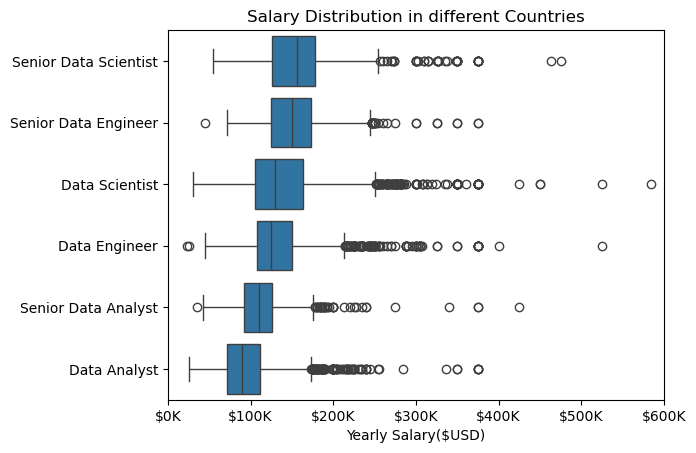

In [32]:
sns.boxplot(data=df_top6, x='salary_year_avg', y='job_title_short', order=job_order)

plt.title('Salary Distribution in different Countries')
plt.xlabel('Yearly Salary($USD)')
plt.ylabel('')
ticks_x = plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.xlim(0,600000)
plt.show() #Removes "MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9;"

## Investigate Median Salary vs Skill for Data Analyst

In [5]:
df_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'].isin(['United States', 'Mexico', 'Germany', 'UK']))].copy()
df_DA = df_DA.dropna(subset=['salary_year_avg'])

In [6]:
df_DA = df_DA.explode('job_skills')
df_DA[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [ ]:
df_DA_top_pay = df_DA.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False).head(10)
df_DA_top_pay

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
terraform,1,166419.5
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0


In [ ]:
df_DA_skills = df_DA.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)
df_DA_skills

,count,median
job_skills,,
sql,2543,92238.5
excel,1831,84500.0
python,1457,97500.0
tableau,1390,92875.0
sas,928,90000.0
...,...,...
theano,1,100000.0
typescript,1,65000.0
vmware,1,147500.0


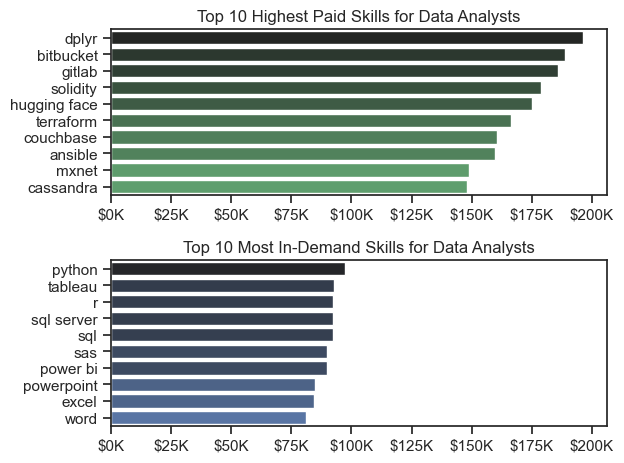

In [26]:
fig, ax = plt.subplots(2, 1)

#Apply Themes to te Charts
sns.set_theme(style='ticks')

sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:g_r')
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].legend().remove()
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='dark:b_r')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].legend().remove()
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()